# Hotel Booking Demand Analysis

## Objective
The objective of this project is to analyze hotel booking data to identify booking patterns, customer behavior, cancellation trends, and other business insights using Python.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots in notebook
%matplotlib inline

# Better looking plots
plt.style.use('ggplot')

# Show all columns
pd.set_option('display.max_columns', None)

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/jessemostipak/hotel-booking-demand/hotel_bookings.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/jessemostipak/hotel-booking-demand/hotel_bookings.csv')

In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
df.shape

(119390, 32)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [7]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [8]:
df1 = df.copy()

In [9]:
df1.duplicated().sum()

np.int64(31994)

In [10]:
df1 = df1.drop_duplicates()

In [11]:
df1.shape

(87396, 32)

In [12]:
df1['children'] = df1['children'].fillna(0)
df1['country'] = df1['country'].fillna('Unknown')
df1['agent'] = df1['agent'].fillna(0)
df1['company'] = df1['company'].fillna(0)

In [13]:
df1.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

# Exploratory Data Analysis (EDA)

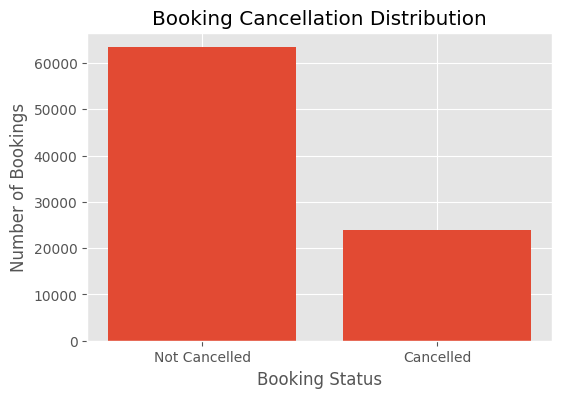

In [14]:
import matplotlib.pyplot as plt

cancel_counts = df1['is_canceled'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(['Not Cancelled', 'Cancelled'], cancel_counts.values)
plt.title('Booking Cancellation Distribution')
plt.xlabel('Booking Status')
plt.ylabel('Number of Bookings')
plt.show()

### Insight

- Most bookings were not cancelled.
- A significant number of bookings were cancelled, indicating that cancellation is an important business issue for hotels.

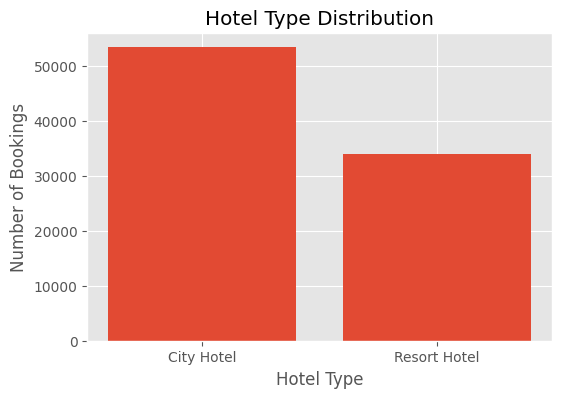

In [15]:
hotel_counts = df1['hotel'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(hotel_counts.index, hotel_counts.values)
plt.title('Hotel Type Distribution')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')
plt.show()

### Insight

- City Hotels receive more bookings than Resort Hotels.
- This suggests that business and urban travel contribute significantly to hotel demand.

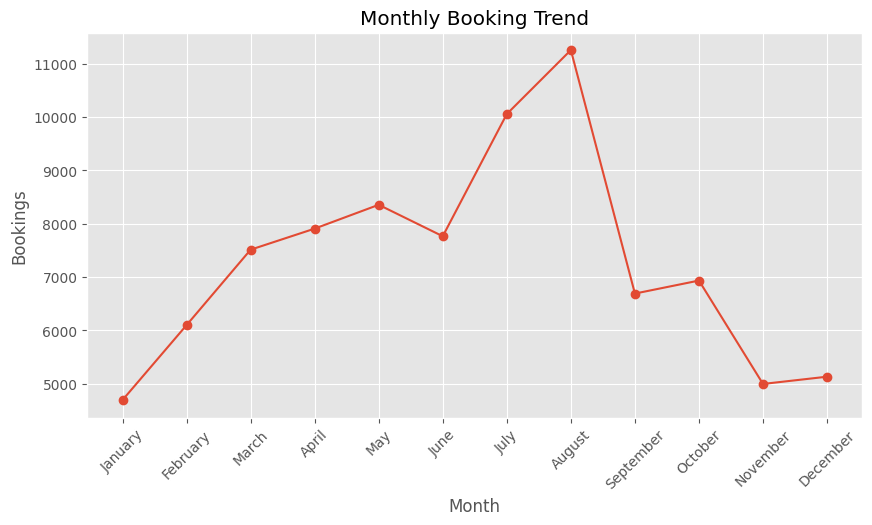

In [16]:
monthly_bookings = df1['arrival_date_month'].value_counts()

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_bookings = monthly_bookings.reindex(month_order)

plt.figure(figsize=(10,5))
plt.plot(monthly_bookings.index, monthly_bookings.values, marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Booking Trend')
plt.xlabel('Month')
plt.ylabel('Bookings')
plt.show()

### Insight

- Booking demand varies throughout the year.
- Peak travel months experience significantly higher bookings than off-season months.

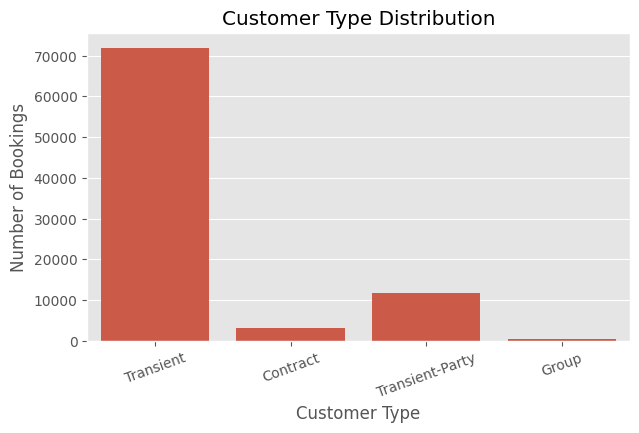

In [17]:
plt.figure(figsize=(7,4))

sns.countplot(x='customer_type', data=df1)

plt.title('Customer Type Distribution')
plt.xlabel('Customer Type')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=20)

plt.show()

### Insight

- Transient customers account for the majority of hotel bookings.
- Contract and group bookings form a much smaller proportion.

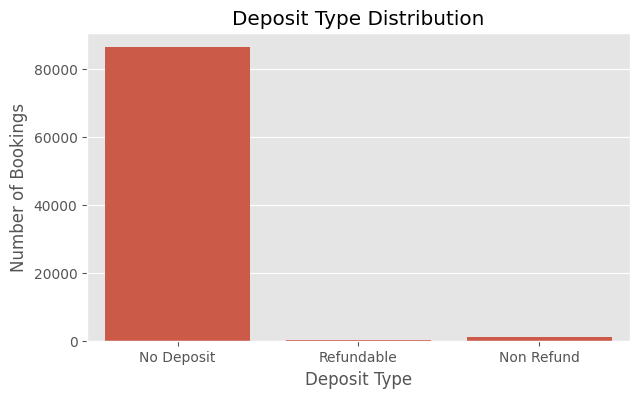

In [18]:
plt.figure(figsize=(7,4))

sns.countplot(x='deposit_type', data=df1)

plt.title('Deposit Type Distribution')
plt.xlabel('Deposit Type')
plt.ylabel('Number of Bookings')

plt.show()

### Insight

- Most customers booked hotels without paying a deposit.
- Only a small percentage of bookings required a deposit.

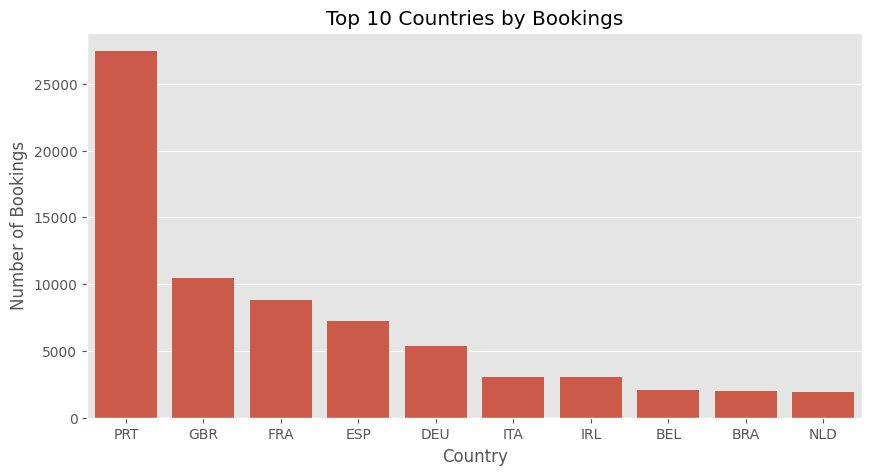

In [19]:
top_country = df1['country'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_country.index,
            y=top_country.values)

plt.title('Top 10 Countries by Bookings')
plt.xlabel('Country')
plt.ylabel('Number of Bookings')

plt.show()

### Insight

- Portugal (PRT) has the highest number of hotel bookings.
- A significant share of bookings comes from European countries.

# Business Insights

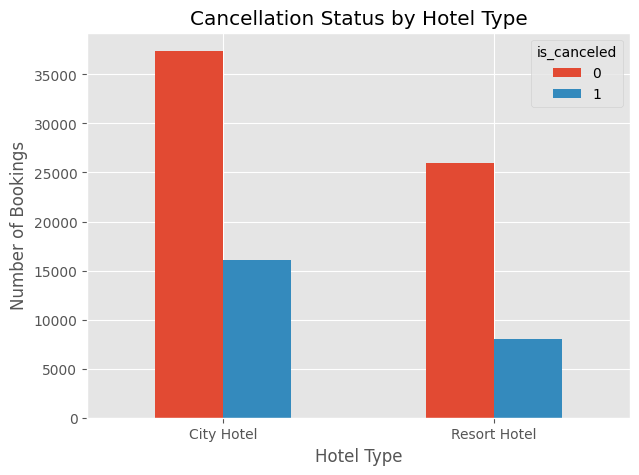

In [20]:
hotel_cancel = pd.crosstab(df1['hotel'], df1['is_canceled'])

hotel_cancel.plot(kind='bar', figsize=(7,5))

plt.title('Cancellation Status by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=0)

plt.show()

### Insight

- Compare cancellations between City Hotels and Resort Hotels.
- This helps hotel management identify which hotel type requires stronger cancellation reduction strategies.

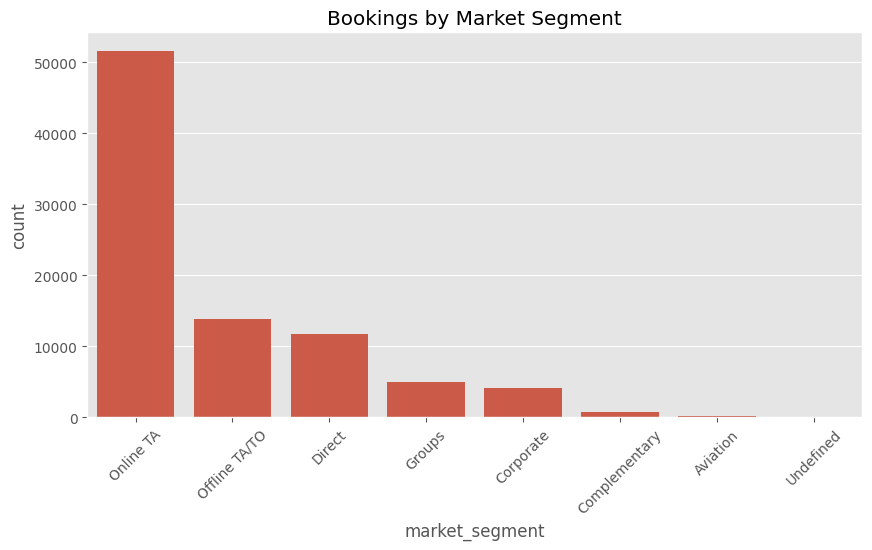

In [21]:
plt.figure(figsize=(10,5))

sns.countplot(data=df1,
              x='market_segment',
              order=df1['market_segment'].value_counts().index)

plt.xticks(rotation=45)

plt.title("Bookings by Market Segment")

plt.show()

### Insight

- Online Travel Agencies (OTA) contribute the highest number of bookings.
- Hotels should strengthen partnerships with online booking platforms.

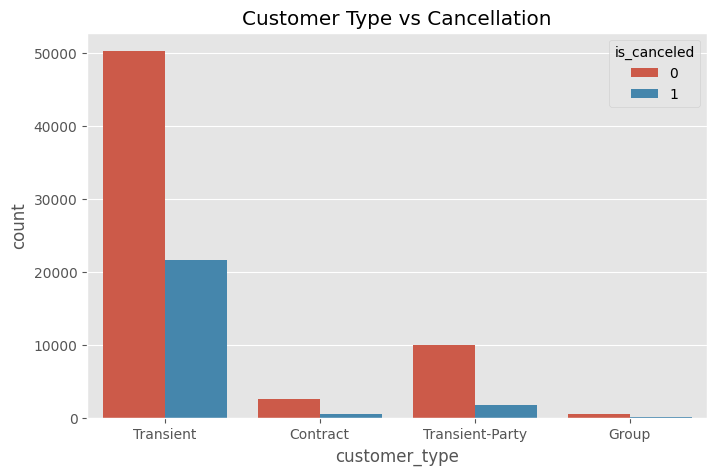

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(data=df1,
              x='customer_type',
              hue='is_canceled')

plt.title("Customer Type vs Cancellation")

plt.show()

### Insight

- Different customer categories have different cancellation behaviours.
- This information helps hotels create targeted booking policies.

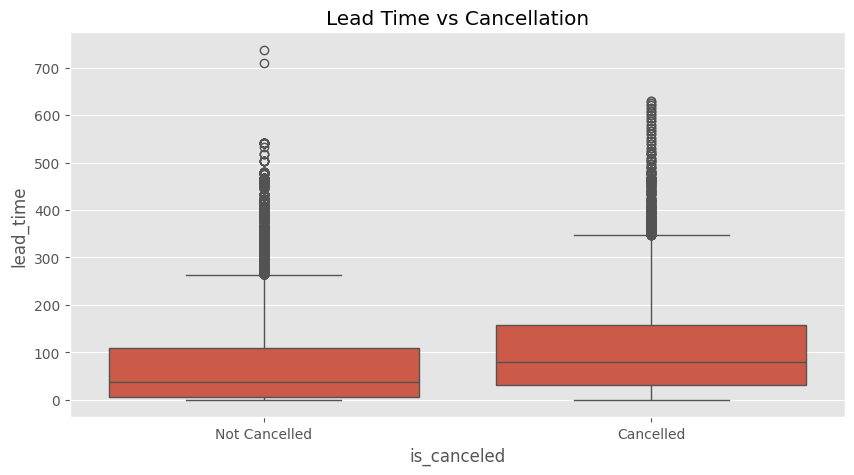

In [23]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df1,
            x='is_canceled',
            y='lead_time')

plt.xticks([0,1],['Not Cancelled','Cancelled'])

plt.title("Lead Time vs Cancellation")

plt.show()

### Insight

- Cancelled bookings generally have higher lead times.
- Customers booking well in advance are more likely to cancel.

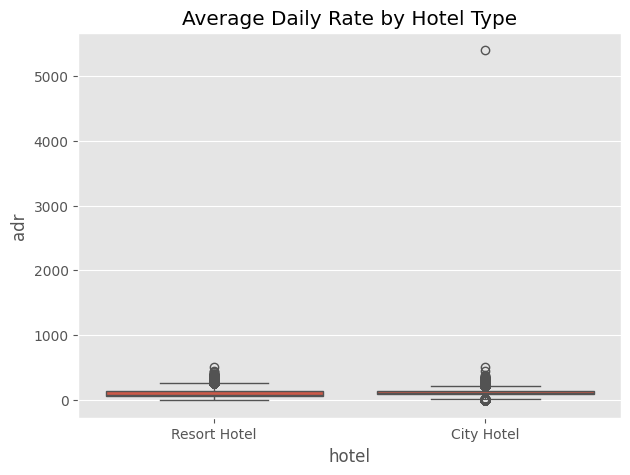

In [24]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df1,
            x='hotel',
            y='adr')

plt.title("Average Daily Rate by Hotel Type")

plt.show()

### Insight

- ADR varies between City Hotels and Resort Hotels.
- Pricing strategies differ depending on hotel type.

# Conclusion

## Key Findings

- City Hotels received more bookings than Resort Hotels.
- Booking cancellations represent a significant operational challenge.
- Peak booking demand occurs during specific months, highlighting seasonal trends.
- Online Travel Agencies (OTA) contribute the largest share of bookings.
- Customers with longer lead times are more likely to cancel.
- Most customers complete bookings without paying a deposit.

## Business Recommendations

- Introduce flexible cancellation policies for early bookings.
- Strengthen partnerships with Online Travel Agencies.
- Develop promotional campaigns during off-peak seasons.
- Optimize pricing strategies based on seasonal demand.

## Project Summary

This project analyzes hotel booking data to understand customer behavior, booking trends, cancellation patterns, and pricing strategies. The analysis uses Python for data cleaning, exploratory data analysis (EDA), and visualization to generate actionable business insights for hotel management.

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Kaggle Notebook

## Dataset Information

- Source: Kaggle – Hotel Booking Demand
- Records (Original): 119,390
- Records (After Cleaning): ~87,396
- Features: 32

## Data Cleaning

- Removed duplicate records.
- Handled missing values in:
  - children
  - country
  - agent
  - company
- Verified data consistency before analysis.